# Fit Models

In [7]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier

from tqdm_joblib import tqdm_joblib
from tqdm.auto import tqdm

from bioacoustics.features import augment_temporal_features, augment_sites

from bioacoustics.data import load_results
from bioacoustics.metrics import evaluate_multilabel_model

from bioacoustics.modeling import FitMode, Classifier, HierarchicalMixtureOfExperts
from bioacoustics.modeling import split_data, get_prediction_pipeline
from bioacoustics.modeling import smooth_proba


from bioacoustics.modeling import get_feature_importance

from bioacoustics.modeling import ignore_warnings

import bioacoustics.visualization  as viz 

ignore_warnings()  # TODO: fix the reasons for these warnings

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Problems to think about:

- Multi-label prediction -> hierarchical models? implement with `Pipeline`
- Class imbalance -> tinker with class weights, adjust probabilities?
- Use additional metadata from train, not available in soundscapes
- Maybe use hybrid approaches? learn about how to combine different models' predictions

think about chunking the audio, tuning the threshold for ech class

## Load features and labels

In [8]:
data_train = load_results("features", "data_train")
data_train_soundscapes = load_results("features", "data_train_soundscapes")

AUGMENT_WITH_TIME = True
AUGMENT_WITH_SITES = True

if AUGMENT_WITH_TIME:
    data_train_soundscapes["X"] = augment_temporal_features(data_train_soundscapes["X"])
if AUGMENT_WITH_SITES:
    data_train_soundscapes["X"] = augment_sites(data_train_soundscapes["X"])

Note that it doesn't make much sense to validate on iNat or XC data, since it's of different format than test soundscapes.

In [9]:
FIT_MODE = FitMode.SOUNDSCAPE_TO_SOUNDSCAPE

X_train, X_test, y_class_train, y_class_test, y_primary_train, y_primary_test = (
    split_data(
        data_train,
        data_train_soundscapes,
        FIT_MODE,
        test_size=0.2,
        random_state=41,
        rare_first=False
    )
)
CLASSIFIER = Classifier.XGBOOST

## Predict class

Start with predicting class only, we may after use this result when predicting primary label.



In [10]:
pipeline_class = get_prediction_pipeline(CLASSIFIER)
with tqdm_joblib(desc="Training OvR", total=y_class_train.shape[1]):
    pipeline_class.fit(X_train, y_class_train)

Training OvR:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
print(f"{FIT_MODE.name} predicting CLASS".center(60))
evaluate_multilabel_model(pipeline_class, X_test, y_class_test)

         SOUNDSCAPE_TO_SOUNDSCAPE predicting CLASS          

================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

    Amphibia       0.99      0.99      0.99       116
        Aves       0.73      0.71      0.72        56
     Insecta       1.00      1.00      1.00        36
    Mammalia       1.00      1.00      1.00         2
    Reptilia       0.00      0.00      0.00         4

   micro avg       0.92      0.90      0.91       214
   macro avg       0.74      0.74      0.74       214
weighted avg       0.91      0.90      0.90       214
 samples avg       0.95      0.93      0.92       214


================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.7424
Micro F1:     0.9125
Hamming loss: 0.0477

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: 0.9766
Micro ROC AUC: 0.9822
Macro AP:      0.9465
Micro AP:      0.9698
LRAP:          0.9581


## Predict species (primary label)

We can use these approaches:

1. **Hierarchical classification:**
    - first predict the class and then train per-class model
    - we must avoid training mismatch - at inference predicted class is used, but at training use only true class, so we better condition on predicted class
    - problems:
        - error propagation if predicted class is wrong
    - **soft version:**
        - $P(s|x) = \sum_c P(s|x,c)P(c|x)$
        - predict class probabilities and use them as soft weights for species classifiers
        - i.e. mixture of experts, soft routing
        - pros:
            - avoids routing errors
            - more consistent as a probability model
    - ideas:
        - I'm afraid class signal will be hidden by hundreds of features, maybe we should emphasize it?
    - multilabel problem:
        - since data is multilabel, classes are not mutually exclusive, it means that when we do an averages sum of preicted probabilities, it will not sum to 1
        - so we would need to normalize it or just do average prediction across experts

1. **Feature augmentation**
    - include predicted class as a new feature:
    - no hard routing, so more robust
    - simple to implement
    - problems:
        - this feature can be noisy
    - **soft version:**
        - include predicted class probabilities as new features

1. Other ideas:
    - hierarchical loss (penalize wrong species but good class less)

We would focus on soft approaches as they are more robust since they avoid noisy hard class assignment.

In [12]:
# TODO: think about OOF prediction (for training data, otherwise prediction is too optimistic)
y_class_train_proba = pipeline_class.predict_proba(X_train)
y_class_test_proba = pipeline_class.predict_proba(X_test)

### Baseline (ignore predicted class)

In [13]:
pipeline_baseline = get_prediction_pipeline(CLASSIFIER)
with tqdm_joblib(desc="Training OvR", total=y_primary_train.shape[1]):
    pipeline_baseline.fit(X_train, y_primary_train)

Training OvR:   0%|          | 0/234 [00:00<?, ?it/s]

In [26]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(ignore CLASS)".center(60))
evaluate_multilabel_model(pipeline_baseline, X_test, y_primary_test)

        SOUNDSCAPE_TO_SOUNDSCAPE predicting SPECIES         
                       (ignore CLASS)                       
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0494  over 34 classes: 0.3397
Micro F1:     0.5210
Hamming loss: 0.0144

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8103
Micro ROC AUC: 0.9472
Macro AP:      0.0721  over 34 classes: 0.4965
Micro AP:      0.5787
LRAP:          0.6167


### Soft hierarchical classification

In [15]:
expert_pipelines = HierarchicalMixtureOfExperts(y_class_test.shape[1], CLASSIFIER)
expert_pipelines.fit(X_train, y_class_train, y_primary_train)

Training expert for Amphibia  :   0%|          | 0/38 [00:00<?, ?it/s]

Training expert for Aves      :   0%|          | 0/54 [00:00<?, ?it/s]

Training expert for Insecta   :   0%|          | 0/47 [00:00<?, ?it/s]

Training expert for Mammalia  :   0%|          | 0/23 [00:00<?, ?it/s]

Training expert for Reptilia  :   0%|          | 0/22 [00:00<?, ?it/s]

In [93]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(soft mixture of CLASS experts)".center(60))
evaluate_multilabel_model(expert_pipelines, X_test, y_primary_test, y_class_test_proba)

        SOUNDSCAPE_TO_SOUNDSCAPE predicting SPECIES         
              (soft mixture of CLASS experts)               
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0542  over 34 classes: 0.3733
Micro F1:     0.5649
Hamming loss: 0.0132

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8339
Micro ROC AUC: 0.9504
Macro AP:      0.0713  over 34 classes: 0.4909
Micro AP:      0.6005
LRAP:          0.6279


### Soft feature augmentation

In [17]:
X_test_augmented = np.concatenate([X_test, y_class_test_proba], axis=1)
X_train_augmented = np.concatenate([X_train, y_class_train_proba], axis=1)

pipeline_augmentation = get_prediction_pipeline(CLASSIFIER)

with tqdm_joblib(desc="Training OvR", total=y_primary_train.shape[1]):
    pipeline_augmentation.fit(X_train_augmented, y_primary_train)

Training OvR:   0%|          | 0/234 [00:00<?, ?it/s]

In [94]:
print(f"{FIT_MODE.name} predicting SPECIES".center(60))
print("(CLASS feature augmentation)".center(60))
evaluate_multilabel_model(pipeline_augmentation, X_test_augmented, y_primary_test)

        SOUNDSCAPE_TO_SOUNDSCAPE predicting SPECIES         
                (CLASS feature augmentation)                
200/234 classes have zero test support — excluded from macro metrics only.

================= THRESHOLD-BASED METRICS ==================
Macro F1:     0.0521  over 34 classes: 0.3586
Micro F1:     0.5335
Hamming loss: 0.0136

============== RANKING & PROBABILITY METRICS ===============
Macro ROC AUC: nan     over 34 classes: 0.8174
Micro ROC AUC: 0.9488
Macro AP:      0.0703  over 34 classes: 0.4838
Micro AP:      0.5839
LRAP:          0.6281


## Postprocessing

In [19]:
# TODO: do temporal smoothing of predicted probabilities (since we know the file and the timestamp)

## Interpret the model

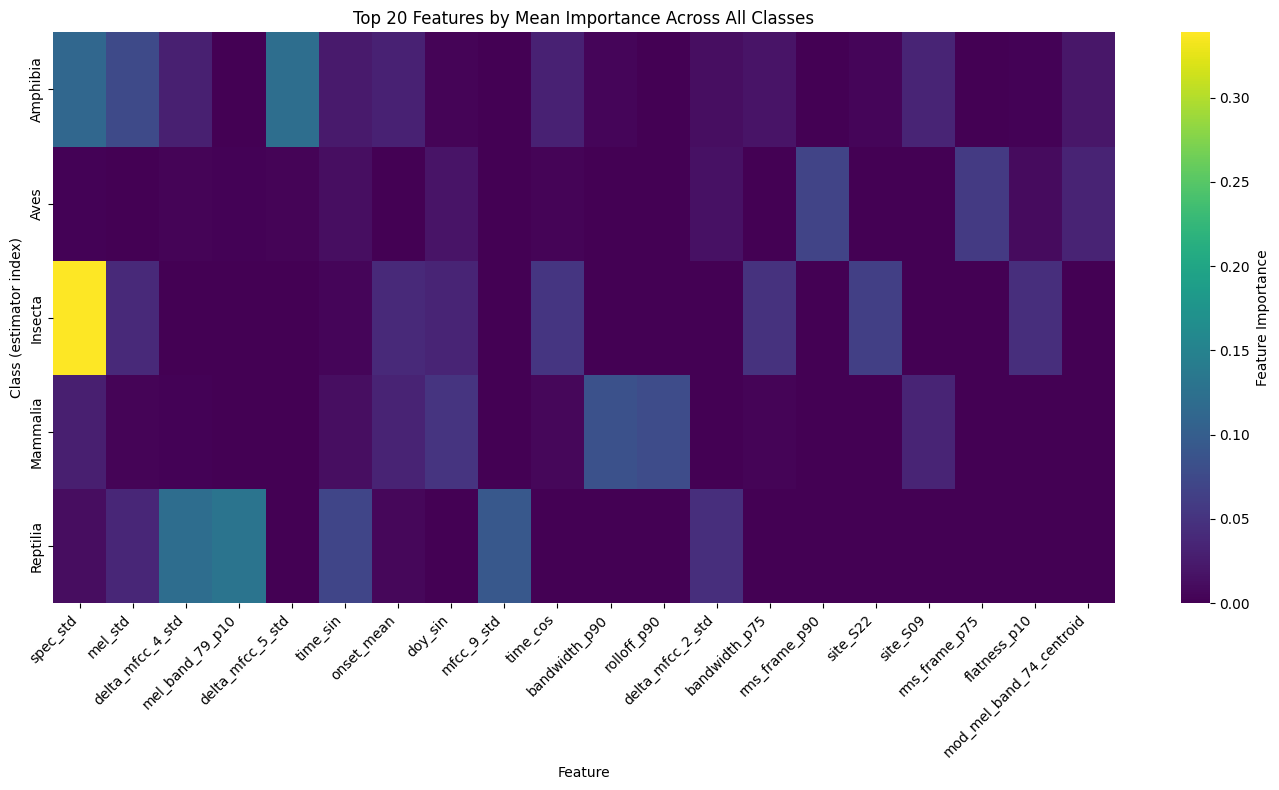

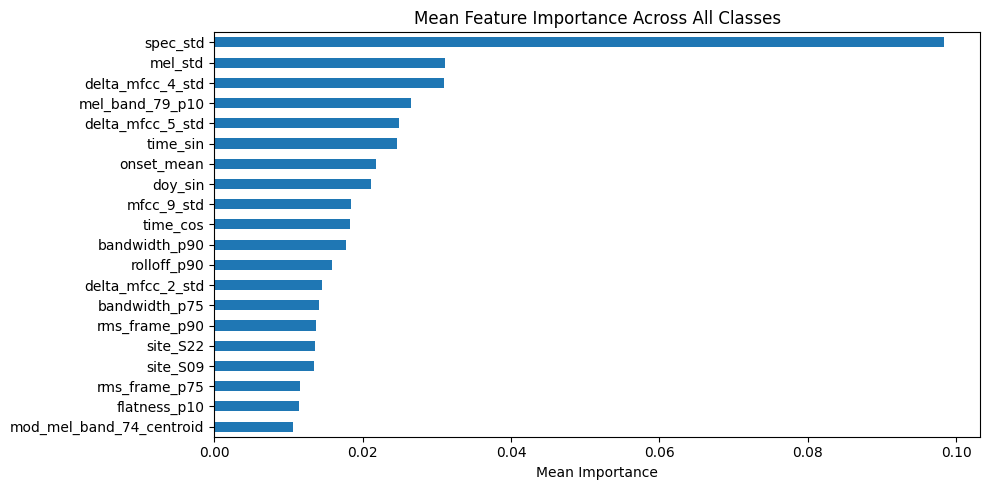

In [95]:
pipeline = pipeline_class
class_names = y_class_train.columns
primary_names = y_primary_train.columns
df_importance = get_feature_importance(pipeline, class_names)
TOP_N = 20
viz.plot_importance_heatmap(df_importance, top_n=TOP_N)
viz.plot_importance_mean(df_importance, top_n=TOP_N)

# SANDBOX

In [21]:
# TODO: the same idea for training metadata that is absent for the test
# - we can learn to predict this metadata as a secondary task and then include
# it in the model

# NOTE: attention to data leak between train - validation when using secondary tasks
# to generate features (class, metadata)

# TODO: can use this metadata as well for stratification - better split validation
# (make sure that there is no data leak because of the same site)
# TODO: check whether metadata alone can predict species (check for shortcut learning)

# TODO: smart cross validations

# TODO: quality of train audio from iNat and xeno-cant is poorer and further from test than train soundscapes,
#       so maybe we should use them only for species poorly covered by soundscapes

# TODO: impute some NaNs

# TODO: maybe stratify be species or sth else since train data had
#   too (really) many bird recordings, whereas soundscapes contain more amphibians

# TODO: maybe play with thresholds

# TODO: temporal smoothing of predicted probabilities!